# DAY2 부록 — 비즈니스 목적을 고려한 추가 실험

단수명 배터리를 오래 사용할 수 있다고 예측하는 오류를 줄일 수 있는지 추가로 탐색했다. 목적·가설 → 비교 조건 → 결과 → 비즈니스 해석 순서로 정리한다.

**이 노트북은 저장된 예측값으로 표·그래프·지표를 재계산하는 분석 노트북이다.** 모델을 새로 학습하거나 새 예측을 만들지 않는다. 폐기한 작업용 학습 코드를 복원한 것이 아니며, 원본 MAT 없이 `Run All`로 결과를 확인할 수 있다. 본문의 고정 모델과 지정 성능표는 유지했다.

Batch2·3는 이미 여러 번 확인한 데이터이므로 아래 점수는 후속 탐색 결과다. 외부 점수가 가장 낮다는 이유로 최종 모델을 교체하지 않았다.

[DAY2 본문](../outputs/day2/DAY2_REPORT.md) · [부록 보고서](../outputs/day2/DAY2_BUSINESS_APPENDIX.md)

In [1]:
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display

sys.dont_write_bytecode = True
cwd = Path.cwd().resolve()
ROOT = next((p for p in [cwd, *cwd.parents]
             if (p / 'outputs/day2/business_appendix/provenance.json').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('프로젝트 루트 또는 notebooks 폴더에서 실행하세요.')
OUT = ROOT / 'outputs/day2/business_appendix'
provenance = json.loads((OUT / 'provenance.json').read_text())

for name, expected in provenance['evidence_sha256'].items():
    assert hashlib.sha256((OUT / name).read_bytes()).hexdigest() == expected, name

predictions = pd.read_csv(OUT / 'predictions.csv', dtype={'cell_id': str})
saved_metrics = pd.read_csv(OUT / 'metrics.csv')
fold_metrics = pd.read_csv(OUT / 'fold_metrics.csv')

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font in ['Apple SD Gothic Neo', 'Malgun Gothic', 'NanumGothic', 'Noto Sans CJK KR']:
    if font in available_fonts:
        plt.rcParams['font.family'] = font
        break
plt.rcParams.update({'font.size': 11, 'axes.unicode_minus': False,
                     'axes.spines.top': False, 'axes.spines.right': False})

print('저장 예측:', len(predictions), '행 / 저장 폴드 점수:', len(fold_metrics), '행')
display(pd.DataFrame([provenance['versions']]).rename(index={0: '실험 당시 환경'}))

저장 예측: 3077 행 / 저장 폴드 점수: 84 행


,python,numpy,pandas,sklearn,scipy
실험 당시 환경,3.11.15,2.4.6,3.0.6,1.9.1,1.17.1


## 1. 왜 추가 실험을 했는가

조기 불량 선별이나 보증 비용 관리에서는 단수명 셀을 놓치는 비용이 클 수 있다. 반면 재사용·자원 활용에서는 장수명 셀의 수명을 너무 짧게 예측하는 것도 낭비를 만든다. 실제 비용 자료는 없으므로 어느 목적이 더 중요하다고 확정하지 않는다.

Batch1의 학습 셀에는 500사이클 미만 사례가 없지만 Batch2에는 많다. 단수명 사례 부족이 과대예측의 주요 원인으로 보이며, 초기 상태와 충전 조건의 배치 차이도 영향을 주었을 가능성이 있다.

**가설:** 같은 초기 특징을 사용하더라도 학습 목표를 바꾸면 단수명 과대예측을 줄일 수 있을까?

In [2]:
# 기존 분할표로 비교 조건을 확인한다. 새로운 분할을 만들지 않는다.
manifest = pd.read_csv(ROOT / 'outputs/day2/protocol_validation/split_manifest.csv',
                       dtype={'cell_id': str})
source_features = pd.read_csv(ROOT / 'outputs/day2/feature_experiments/cell_features.csv',
                             dtype={'cell_id': str})
development = manifest.loc[manifest.role.eq('development')].merge(
    source_features, on=['batch', 'cell_id'], validate='one_to_one')
holdout_ids = set(manifest.loc[manifest.role.eq('holdout'), 'cell_id'])
assert len(development) == 29 and len(holdout_ids) == 7
assert not set(development.cell_id) & holdout_ids
assert development.input_max_cycle.le(100).all()
assert not set(manifest.loc[manifest.role.eq('development'), 'protocol']) & set(
    manifest.loc[manifest.role.eq('holdout'), 'protocol'])

reference = predictions.loc[predictions.experiment.eq('shortlife_objective')
                            & predictions.split.eq('protocol29')
                            & predictions.candidate.eq('baseline')]
rows = [{'집단': 'Batch1 학습', '셀 수': len(development),
         '최소 수명': development.cycle_life.min(), '최대 수명': development.cycle_life.max(),
         '500 미만 셀 수': int(development.cycle_life.lt(500).sum())}]
for batch in ['Holdout', 'Batch2', 'Batch3']:
    data = reference.loc[reference.evaluation.eq(batch)]
    rows.append({'집단': batch, '셀 수': len(data), '최소 수명': data.cycle_life.min(),
                 '최대 수명': data.cycle_life.max(),
                 '500 미만 셀 수': int(data.cycle_life.lt(500).sum())})
display(pd.DataFrame(rows).set_index('집단'))

,셀 수,최소 수명,최대 수명,500 미만 셀 수
집단,,,,
Batch1 학습,29,534.0,1054.0,0
Holdout,7,636.0,1074.0,0
Batch2,39,392.0,1186.0,28
Batch3,44,541.0,1935.0,0


## 2. 무엇을 바꿨는가

주 비교는 동일한 Batch1 학습 29셀·Hold-out 7셀이다. 입력은 **초기 100사이클의 ΔQ 로그 분산 하나**로 유지했다. 당시 실행에서는 결측 대체와 표준화를 각 학습 폴드 안에서 fit했다.

| 후보 | 학습 목표와 가설 |
| --- | --- |
| 기존 선형모델 | 수명 자체의 제곱오차를 최소화하는 기준 모델 |
| 수명의 역수 학습 | `1000 / 수명`을 열화 속도의 대리값으로 학습. 수명과 속도의 역관계가 외삽에 도움이 되는지 확인 |
| 분위수 0.5 | 조건부 중앙값을 예측. 절대오차 기반 학습으로 큰 오차의 영향을 줄이는지 확인 |
| 분위수 0.3 | 수명 과대예측에 더 큰 비용을 두어 단수명 셀을 덜 놓치는지 확인 |

역수 모델은 표준화한 로그 분산 `z`에 대해 `r = softplus(c + b*z), b >= 0`를 사용했다. `r`이 양수가 되도록 설계하고 `예측 수명 = 1000 / r`로 역변환했다. `1000`은 고정 단위 변환이다. 일정한 열화 속도를 입증한 물리 모델은 아니다.

분위수 회귀는 `alpha=0`, `solver='highs'`로 고정했다. 분위수 0.3의 손실은 실제보다 길게 예측한 오차에 0.7, 짧게 예측한 오차에 0.3의 비중을 둔다. 분위수 0.3을 검증된 수명 보증 하한으로 해석하지 않는다.

아래 노트북 코드는 위 모델을 다시 fit하는 것이 아니라, 당시 저장된 예측으로 결과를 확인한다.

## 3. 저장된 예측에서 지표를 다시 계산

MAPE는 셀별 `|예측 - 실제| / 실제 × 100`의 평균이다. 짧은 수명에서는 같은 사이클 오차도 더 큰 비율로 평가된다. MAPE를 정확도로 바꿔 해석하지 않는다.

`bias_cycles = 평균(예측 - 실제)`는 양수일 때 과대예측, 음수일 때 과소예측이다. 평균 과대예측량은 `평균(max(예측 - 실제, 0))`이며 해당 집단의 모든 셀을 분모에 포함한다.

In [3]:
KEYS = ['experiment', 'split', 'candidate', 'evaluation']
assert not predictions.duplicated(KEYS + ['cell_id']).any()
assert np.isfinite(predictions[['cycle_life', 'prediction']]).all().all()
assert predictions.cycle_life.gt(100).all()
np.testing.assert_allclose(predictions.ape_pct,
    100 * abs(predictions.prediction - predictions.cycle_life) / predictions.cycle_life)

rows = []
for key, group in predictions.groupby(KEYS, sort=False):
    masks = {'all': np.ones(len(group), dtype=bool),
             'short_lt500': group.cycle_life.lt(500).to_numpy(),
             'other_ge500': group.cycle_life.ge(500).to_numpy()}
    for segment, mask in masks.items():
        data = group.loc[mask]
        if data.empty:
            continue
        error = data.prediction - data.cycle_life
        rows.append(dict(zip(KEYS, key), segment=segment, n=len(data),
            mape_pct=float((100 * abs(error) / data.cycle_life).mean()),
            mae=float(abs(error).mean()), rmse=float(np.sqrt(np.mean(error**2))),
            bias_cycles=float(error.mean()),
            mean_positive_overprediction=float(error.clip(lower=0).mean()),
            overprediction_pct=float(100 * (error > 0).mean())))
metrics = pd.DataFrame(rows)
checked = metrics.merge(saved_metrics, on=KEYS + ['segment'],
                        suffixes=('_check', '_saved'), validate='one_to_one')
assert len(checked) == len(metrics) == len(saved_metrics)
for column in ['n', 'mape_pct', 'mae', 'rmse', 'bias_cycles',
               'mean_positive_overprediction', 'overprediction_pct']:
    np.testing.assert_allclose(checked[column + '_check'], checked[column + '_saved'],
                               rtol=1e-9, atol=1e-9)
print('검산 통과:', len(metrics), '개 평가 행이 저장 결과와 일치')

검산 통과: 238 개 평가 행이 저장 결과와 일치


## 4. Batch1 안에서는 어떤 후보를 선택했는가

일반 검증은 기존 프로토콜 5-fold 평균이다. 추가 검증은 개발 셀 중 수명이 짧은 하위 20% 또는 30%를 검증에 두고, 긴 나머지 셀로 학습한 결과다. 동일 프로토콜이 검증에 있으면 해당 학습 셀도 제외했다.

두 단수명 검증 집단은 겹치므로 그 평균을 독립적인 CV 점수로 보지 않는다. Batch2 점수로 검증 방식이나 모델을 다시 선택하지 않았다.

In [4]:
CANDIDATES = ['baseline', 'inverse', 'q50', 'q30']
LABELS = {'baseline': '기존 선형모델', 'inverse': '수명의 역수',
          'q50': '분위수 0.5', 'q30': '분위수 0.3'}
COLORS = {'baseline': '#777777', 'inverse': '#4c89b5',
          'q50': '#70a68a', 'q30': '#dc9b46'}
objective_folds = fold_metrics.loc[fold_metrics.experiment.eq('shortlife_objective')]
cv = objective_folds.groupby(['split', 'candidate', 'regime']).mape_pct.mean().unstack('regime')
primary_cv = cv.loc['protocol29'].reindex(CANDIDATES)
display(primary_cv.rename(index=LABELS,
    columns={'normal': '일반 CV MAPE (%)', 'stress': '긴 수명→짧은 수명 MAPE (%)'}).round(2))

for split, selections in provenance['objective_selection'].items():
    for regime, expected in selections.items():
        values = cv.loc[split].reindex(CANDIDATES)[regime]
        assert values.idxmin() == expected
print('주 비교의 일반 CV 선택:', LABELS[provenance['objective_selection']['protocol29']['normal']])
print('주 비교의 단수명 검증 선택:', LABELS[provenance['objective_selection']['protocol29']['stress']])

stress = pd.DataFrame(provenance['stress_splits'])
assert stress.protocol_overlap.eq(0).all()
assert stress.train_min.gt(stress.valid_max).all()
display(stress.loc[stress.split.eq('protocol29'),
    ['scenario', 'n_train', 'n_valid', 'train_min', 'valid_max']].rename(columns={
        'scenario': '단수명 검증 비율', 'n_train': '학습 셀 수', 'n_valid': '검증 셀 수',
        'train_min': '학습 최소 수명', 'valid_max': '검증 최대 수명'}))

regime,일반 CV MAPE (%),긴 수명→짧은 수명 MAPE (%)
candidate,,
기존 선형모델,7.93,12.73
수명의 역수,8.43,14.21
분위수 0.5,7.58,11.30
분위수 0.3,8.42,7.09


주 비교의 일반 CV 선택: 분위수 0.5
주 비교의 단수명 검증 선택: 분위수 0.3


,단수명 검증 비율,학습 셀 수,검증 셀 수,학습 최소 수명,검증 최대 수명
0,0.2,23,6,651.0,625.0
1,0.3,19,9,703.0,702.0


일반 CV는 분위수 0.5, 짧은 수명 방향의 검증은 분위수 0.3을 선택했다. **모델을 평가하는 목적에 따라 선택이 달라졌다.** 이 선택을 먼저 고정한 뒤 사전에 정한 네 후보의 외부 결과를 비교했다.

## 5. 동일한 학습 셀에서 Batch2·3 비교

,Batch1 CV (%),Batch1 Hold-out (%),Batch2 (%),Batch3 (%)
기존 선형모델,7.93,10.73,28.68,12.09
수명의 역수,8.43,8.74,30.24,13.33
분위수 0.5,7.58,10.90,26.16,12.76
분위수 0.3,8.42,12.29,25.44,14.59


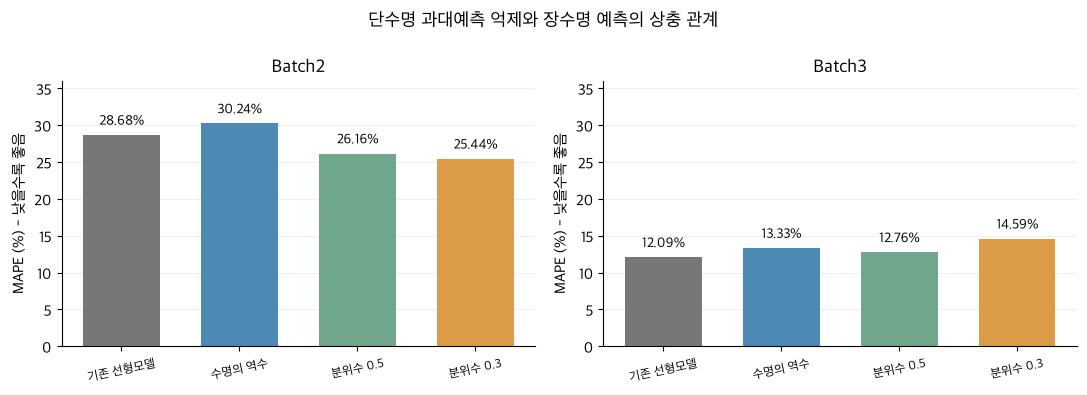

In [5]:
def objective_table(split):
    scores = metrics.loc[metrics.experiment.eq('shortlife_objective')
                         & metrics.split.eq(split) & metrics.segment.eq('all')]
    external = scores.pivot(index='candidate', columns='evaluation', values='mape_pct')
    table = pd.DataFrame(index=CANDIDATES)
    table['Batch1 CV (%)'] = cv.loc[split].reindex(CANDIDATES)['normal']
    for batch, label in [('Holdout', 'Batch1 Hold-out (%)'),
                         ('Batch2', 'Batch2 (%)'), ('Batch3', 'Batch3 (%)')]:
        table[label] = external.reindex(CANDIDATES)[batch]
    return table.rename(index=LABELS).round(2)

display(objective_table('protocol29'))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, batch in zip(axes, ['Batch2', 'Batch3']):
    scores = metrics.loc[metrics.experiment.eq('shortlife_objective')
                         & metrics.split.eq('protocol29') & metrics.segment.eq('all')
                         & metrics.evaluation.eq(batch)].set_index('candidate')
    values = scores.loc[CANDIDATES, 'mape_pct'].to_numpy()
    bars = ax.bar(range(4), values, color=[COLORS[c] for c in CANDIDATES], width=.65)
    ax.bar_label(bars, labels=[f'{value:.2f}%' for value in values], padding=4, fontsize=10)
    ax.set_xticks(range(4), [LABELS[c] for c in CANDIDATES], rotation=12, fontsize=9)
    ax.set_title(batch); ax.set_ylabel('MAPE (%) - 낮을수록 좋음'); ax.set_ylim(0, 36)
    ax.grid(axis='y', alpha=.2); ax.set_axisbelow(True)
fig.suptitle('단수명 과대예측 억제와 장수명 예측의 상충 관계', fontsize=13)
fig.tight_layout(); plt.show()

**확인한 결과:** 역수 학습은 두 외부 배치 모두 개선하지 못했다. 분위수 0.3은 Batch2 MAPE를 28.68%→25.44%로 낮췄지만 Batch3는 12.09%→14.59%로 높였다. 분위수 0.5는 Batch2 26.16%, Batch3 12.76%로 변화가 더 완만했다.

분위수 0.3의 이점은 모든 수명을 더 정확하게 예측했다는 뜻이 아니다. 오류 방향이 비즈니스 목적에 가까워졌는지 다음에서 확인한다.

## 6. 단수명 과대예측은 얼마나 줄었는가

,셀 수,단수명 MAPE (%),평균 과대예측 (사이클),과대예측 셀 비율 (%)
candidate,,,,
기존 선형모델,28,32.84,145.80,100.0
수명의 역수,28,33.97,150.42,100.0
분위수 0.5,28,29.78,132.10,100.0
분위수 0.3,28,29.05,128.67,100.0


,Batch3 평균 예측-실제 (사이클),Batch3 MAE (사이클),Batch3 MAPE (%)
candidate,,,
기존 선형모델,-85.66,150.22,12.09
수명의 역수,0.64,157.13,13.33
분위수 0.5,-112.60,161.09,12.76
분위수 0.3,-159.89,186.84,14.59


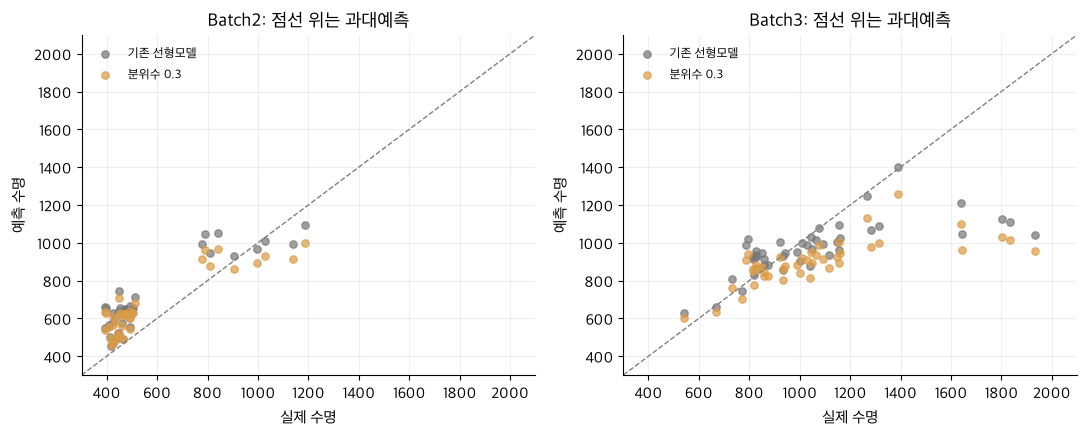

In [6]:
short = metrics.loc[metrics.experiment.eq('shortlife_objective')
                    & metrics.split.eq('protocol29') & metrics.evaluation.eq('Batch2')
                    & metrics.segment.eq('short_lt500')].set_index('candidate').reindex(CANDIDATES)
long_batch = metrics.loc[metrics.experiment.eq('shortlife_objective')
                         & metrics.split.eq('protocol29') & metrics.evaluation.eq('Batch3')
                         & metrics.segment.eq('all')].set_index('candidate').reindex(CANDIDATES)
assert short.n.eq(28).all()
display(short[['n', 'mape_pct', 'mean_positive_overprediction', 'overprediction_pct']]
        .rename(index=LABELS, columns={'n': '셀 수', 'mape_pct': '단수명 MAPE (%)',
         'mean_positive_overprediction': '평균 과대예측 (사이클)',
         'overprediction_pct': '과대예측 셀 비율 (%)'}).round(2))
display(long_batch[['bias_cycles', 'mae', 'mape_pct']].rename(index=LABELS, columns={
    'bias_cycles': 'Batch3 평균 예측-실제 (사이클)', 'mae': 'Batch3 MAE (사이클)',
    'mape_pct': 'Batch3 MAPE (%)'}).round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, batch in zip(axes, ['Batch2', 'Batch3']):
    for candidate in ['baseline', 'q30']:
        data = predictions.loc[predictions.experiment.eq('shortlife_objective')
                               & predictions.split.eq('protocol29')
                               & predictions.evaluation.eq(batch)
                               & predictions.candidate.eq(candidate)]
        ax.scatter(data.cycle_life, data.prediction, color=COLORS[candidate],
                   label=LABELS[candidate], alpha=.7, s=28)
    ax.plot([300, 2100], [300, 2100], '--', color='gray', linewidth=1)
    ax.set_xlim(300, 2100); ax.set_ylim(300, 2100)
    ax.set_title(batch + ': 점선 위는 과대예측'); ax.set_xlabel('실제 수명'); ax.set_ylabel('예측 수명')
    ax.grid(alpha=.2); ax.legend(frameon=False, fontsize=9)
fig.tight_layout(); plt.show()

분위수 0.3은 Batch2 단수명 셀의 평균 과대예측을 **145.8→128.7사이클**로 줄였다. 하지만 해당 28셀 모두 여전히 과대예측했다. Batch3에서는 평균 예측-실제가 **-85.7→-159.9사이클**로 더 음수가 됐다. 더 긴 실제 수명을 너무 짧게 예측하는 경향이 커졌다.

**비즈니스 해석:** 단수명을 놓치는 비용을 줄이는 목적에는 도움이 될 수 있으나, 사용 가능한 수명을 과소평가하는 비용을 함께 확인해야 한다. 그 비용이나 운영 임계값을 실제로 최적화한 실험은 아니다.

## 7. 예전 학습 28셀에서도 같은 결과였는가

새 분할과 예전 분할은 학습 셀이 다르다. 각 분할 안에서 기존 모델과 비교하고, 두 점수의 차이를 분리 방식 하나의 효과로 해석하지 않는다.

In [7]:
display(objective_table('historical28'))

,Batch1 CV (%),Batch1 Hold-out (%),Batch2 (%),Batch3 (%)
기존 선형모델,9.28,6.44,26.19,11.94
수명의 역수,9.33,6.18,29.18,13.33
분위수 0.5,9.99,7.31,23.84,12.00
분위수 0.3,9.75,8.53,24.71,14.55


예전 28셀 구성에서 분위수 0.5의 Batch2/3 MAPE는 **23.84% / 12.00%**였다. 기존 **26.19% / 11.94%**보다 Batch2는 좋아지고 Batch3는 거의 같았다. 반면 Batch1 CV는 9.28%→9.99%, Hold-out은 6.44%→7.31%로 나빠졌다.

개선 관측 자체는 남겼지만 사후 외부 점수만으로 최종 모델을 바꾸지 않았다. 본문의 26.19%는 본문 개발 범위의 관측 최저이며, 이후 모든 탐색을 합친 최저라는 의미는 아니다.

## 8. 그 밖의 추가 실험 — 핵심만 확인

분포 변환·정렬, 단수명 방향의 검증, 초기 변화 진행 특징도 비교했다. 아래는 저장 결과 중 대표적인 비교만 보여준다.

In [8]:
# 예전 28셀 분리 안에서의 대표 스케일링·정렬 결과
methods = ['baseline', 'y_standard', 'y_log', 'relative_q', 'coral_spread', 'importance']
method_labels = {'baseline': '기존 모델', 'y_standard': '수명 표준화', 'y_log': '수명 로그 변환',
                 'relative_q': '초기 용량으로 ΔQ 분산 보정', 'coral_spread': 'CORAL 퍼짐 정렬',
                 'importance': '외부 입력과 비슷한 학습 셀에 가중치'}
scaling = metrics.loc[metrics.experiment.eq('scaling') & metrics.split.eq('historical28')
                      & metrics.segment.eq('all') & metrics.evaluation.isin(['Batch2', 'Batch3'])]
comparison = scaling.pivot(index='candidate', columns='evaluation', values='mape_pct').reindex(methods)
uses_external = predictions.loc[predictions.experiment.eq('scaling')
                               & predictions.split.eq('historical28')].groupby('candidate').uses_external_inputs.first()
comparison['외부 초기 입력 사용'] = comparison.index.map(uses_external).map({True: '예', False: '아니오'})
display(comparison.rename(index=method_labels,
                         columns={'Batch2': 'Batch2 MAPE (%)', 'Batch3': 'Batch3 MAPE (%)'}).round(2))

# 초기 변화 진행 특징은 동일 전압 격자에서 두 구간의 변화 속도를 비교했다.
progress = metrics.loc[metrics.experiment.eq('early_progress') & metrics.segment.eq('all')
                       & metrics.evaluation.isin(['Batch2', 'Batch3'])]
progress_table = progress.pivot(index=['split', 'candidate'], columns='evaluation', values='mape_pct')
display(progress_table.rename(index={'protocol29': '프로토콜 분리 29셀',
    'historical28': '예전 셀 분리 28셀', 'core_raw_ols': '기존 분산 1개',
    'progress_raw_ols': '초기 변화 진행 특징 추가'}).round(2))

progress_cv = fold_metrics.loc[fold_metrics.experiment.eq('early_progress')]
display(progress_cv.groupby(['split', 'candidate', 'regime']).mape_pct.mean()
        .unstack('regime').round(2))

evaluation,Batch2 MAPE (%),Batch3 MAPE (%),외부 초기 입력 사용
candidate,,,
기존 모델,26.19,11.94,아니오
수명 표준화,26.19,11.94,아니오
수명 로그 변환,28.62,12.35,아니오
초기 용량으로 ΔQ 분산 보정,26.77,11.82,아니오
CORAL 퍼짐 정렬,43.33,13.34,예
외부 입력과 비슷한 학습 셀에 가중치,25.63,12.14,예


evaluation                  Batch2  Batch3
split       candidate                     
예전 셀 분리 28셀 기존 분산 1개         26.19   11.94
            초기 변화 진행 특징 추가   26.19   11.94
프로토콜 분리 29셀 기존 분산 1개         28.68   12.09
            초기 변화 진행 특징 추가   26.30   12.03

regime                         normal  stress
split        candidate                       
historical28 core_raw_ols        9.28   15.82
             progress_raw_ols    9.66   16.36
protocol29   core_raw_ols        7.93   12.73
             progress_raw_ols    8.34   12.50

수명 표준화는 예측 성능을 바꾸지 않았다. CORAL 퍼짐 정렬은 예전 모델의 Batch2/3를 **43.33% / 13.34%**로 악화시켰다. 외부 입력과 비슷한 학습 셀에 가중치를 주는 방법은 Batch2가 소폭 좋아졌지만 Batch3는 개선하지 못했다.

CORAL과 가중치 방법은 외부 배치의 정답 없는 초기 입력까지 사용한다. **Batch1만으로 전처리 기준을 fit하는 설정과 다르다.** 분포 그림만 비교한 다른 변환은 모델 성능 실험으로 계산하지 않았다.

초기 변화 진행 특징은 다음 값이었다.

$$
\log_{10}\operatorname{Var}\left(\frac{Q_{100}-Q_{50}}{50}\right)
-\log_{10}\operatorname{Var}\left(\frac{Q_{50}-Q_{10}}{40}\right)
$$

양수이면 후반 구간의 사이클당 변화 분산이 더 크다. 초기 변화가 커지는지에 대한 대리 특징이며 실제 knee 검출값은 아니다. 프로토콜 분리의 Batch2/3는 **26.30% / 12.03%**였지만 예전 학습 셀에서는 거의 변화가 없었다. 효과가 학습 셀 구성에 따라 달랐다.

긴 수명→짧은 수명 검증 기준만 바꾼 경우에는 분산 하나의 기존 선형모델이 다시 선택되어 예측이 같았다. 검증 기준 변경만으로 부족한 단수명 정보를 만들어내지는 못했다.

## 9. 비즈니스 목적별 결론

| 목적 | 확인한 내용 | 실무 적용 전에 필요한 확인 |
| --- | --- | --- |
| 조기 불량 선별·보증 비용 관리 | 보수적 예측은 단수명 과대예측을 줄일 수 있음 | 불량을 놓치는 비용과 정상 셀을 불량으로 판단하는 비용을 함께 평가 |
| 교체 시점 계획 | 점추정만으로 교체 시점을 확정하기 어려움 | 예측 구간·하위 분위수의 실제 포함률과 새 배치에서의 신뢰성 검증 |
| 재사용·자원 활용 | 보수적 예측은 장수명 셀을 너무 일찍 제외할 수 있음 | 과소예측으로 발생하는 사용 가능 수명 손실을 평가 |

**단수명 과대예측을 일부 줄였지만, 장수명 예측과의 균형이 남았다.** 모델을 더 복잡하게 만드는 것보다는 학습 데이터가 짧은 수명부터 긴 수명까지 고르게 포함하도록 보완하는 방향이 유망해 보인다.

단수명 사례와 다양한 운영 조건의 데이터를 보완하면 짧은 수명 예측도 개선될 것으로 기대한다. 운영 목적에 맞게 과대·과소예측의 비용을 정하고, 새 배치에서 개선 정도를 확인하면 좋겠다. 이번 실험은 점예측 비교이며, 수명 보증에 필요한 예측 구간 검증은 별도 과제다.

추가 개발은 종료했다. 이 부록은 최종 모델 채택 기록이 아니라, 목적에 따른 이점과 손해를 확인한 후속 탐색 기록이다.

## 10. 실행 후 확인

원본 MAT·폐기한 실험 학습 코드 없이 저장 결과를 검산했다. 아래 확인은 보존한 CSV와 본문 고정 모델이 바뀌지 않았는지 검사한다. 그림은 화면에만 표시하며 보고서·모델 파일을 덮어쓰지 않는다.

원논문의 공식 코드는 처음 두 수집 배치를 합친 집합에서 학습·주 테스트를 분리한다. 우리 과제보다 다양한 수명 사례를 학습하는 데 유리했을 것으로 예상한다. 사용 데이터와 설정도 달라 9.1%는 참고 기준으로 비교한다. [공식 분할 코드](https://github.com/rdbraatz/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation/blob/master/LoadData.m) · [원논문](https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf)

In [9]:
for name, expected in provenance['evidence_sha256'].items():
    assert hashlib.sha256((OUT / name).read_bytes()).hexdigest() == expected, name
for relative, expected in provenance['frozen_main_model_sha256'].items():
    assert hashlib.sha256((ROOT / relative).read_bytes()).hexdigest() == expected, relative
print('확인 완료: 저장 지표 재계산 일치 · CSV 무결성 유지 · 본문 고정 모델 변경 없음')

확인 완료: 저장 지표 재계산 일치 · CSV 무결성 유지 · 본문 고정 모델 변경 없음
